<a href="https://colab.research.google.com/github/rasikacs23172/mechine-learning-tae/blob/main/model1_DTR_70_30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Mount Google Drive

First, we'll mount your Google Drive. While the provided CSV is in `/content/`, mounting your drive is a common first step and allows for access to other files if needed.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 2: Load the Dataset

Now, we'll load the `/content/student-mat (1).csv` file into a pandas DataFrame. We'll then inspect its first few rows to understand its structure.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

# Load the specified dataset, specifying semicolon as the separator
df = pd.read_csv('/content/student-mat (1).csv', sep=';')

print("Dataset loaded successfully:")
display(df.head())

print("\nDataset Information:")
df.info()

Dataset loaded successfully:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    

### Step 3: Define Basic Variables (Features and Target)

Based on the `student-mat (1).csv` dataset, we'll define 'G3' (final grade) as our target variable `y` for regression. For features `X`, we'll select 'G1' (first period grade), 'G2' (second period grade), 'age', and 'absences' as numerical predictors. We'll then ensure all chosen features are numerical.

In [ ]:
# Define features (X) and target (y) for regression
feature_columns = ['G1', 'G2', 'age', 'absences'] # Selecting relevant numerical features
target_column = 'G3'

X = df[feature_columns]
y = df[target_column]

# Ensure all features are numerical (Decision Tree Regressor works best with numerical input)
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Drop rows with NaN values that might have been introduced by 'coerce'
df_cleaned = pd.concat([X, y], axis=1).dropna()
X = df_cleaned[feature_columns]
y = df_cleaned[target_column]


print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
display(X.head())
display(y.head())

Features (X) shape: (395, 4)
Target (y) shape: (395,)


,G1,G2,age,absences
0,5,6,18,6
1,5,5,17,4
2,7,8,15,10
3,15,14,15,2
4,6,10,16,4


,G3
0,6
1,6
2,10
3,15
4,10


### Step 4: Split the Data (70:30 Split)

We'll split our dataset into training (70%) and testing (30%) sets. This allows us to evaluate the model's performance on unseen data.

In [ ]:
# Split data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (276, 4)
X_test shape: (119, 4)
y_train shape: (276,)
y_test shape: (119,)


### Step 5: Train Three Decision Tree Regressors

We will train three Decision Tree Regressor models, each with a different `max_depth` to demonstrate how model complexity affects performance and to find a reasonable balance between bias and variance.

In [ ]:
# Model 1: Basic Decision Tree Regressor (default depth)
dt_regressor_1 = DecisionTreeRegressor(random_state=42)
dt_regressor_1.fit(X_train, y_train)

# Model 2: Decision Tree Regressor with max_depth=3 (shallow)
dt_regressor_2 = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_regressor_2.fit(X_train, y_train)

# Model 3: Decision Tree Regressor with max_depth=10 (deep)
dt_regressor_3 = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_regressor_3.fit(X_train, y_train)

print("Three Decision Tree Regressors trained with varying max_depth.")

Three Decision Tree Regressors trained with varying max_depth.


### Step 6: Evaluate Models and Visualize Predictions

Finally, we'll evaluate each model using Mean Squared Error (MSE) and R-squared (R2) score. We'll also visualize their predictions against the actual test data. For visualization, since we have multiple features, we'll plot the predictions against the actual values to see how well each model fits the data.


--- Default Depth ---
Mean Squared Error (MSE): 4.8950
R-squared (R2) Score: 0.7773

--- Max Depth = 3 ---
Mean Squared Error (MSE): 3.8800
R-squared (R2) Score: 0.8235

--- Max Depth = 10 ---
Mean Squared Error (MSE): 4.8527
R-squared (R2) Score: 0.7792


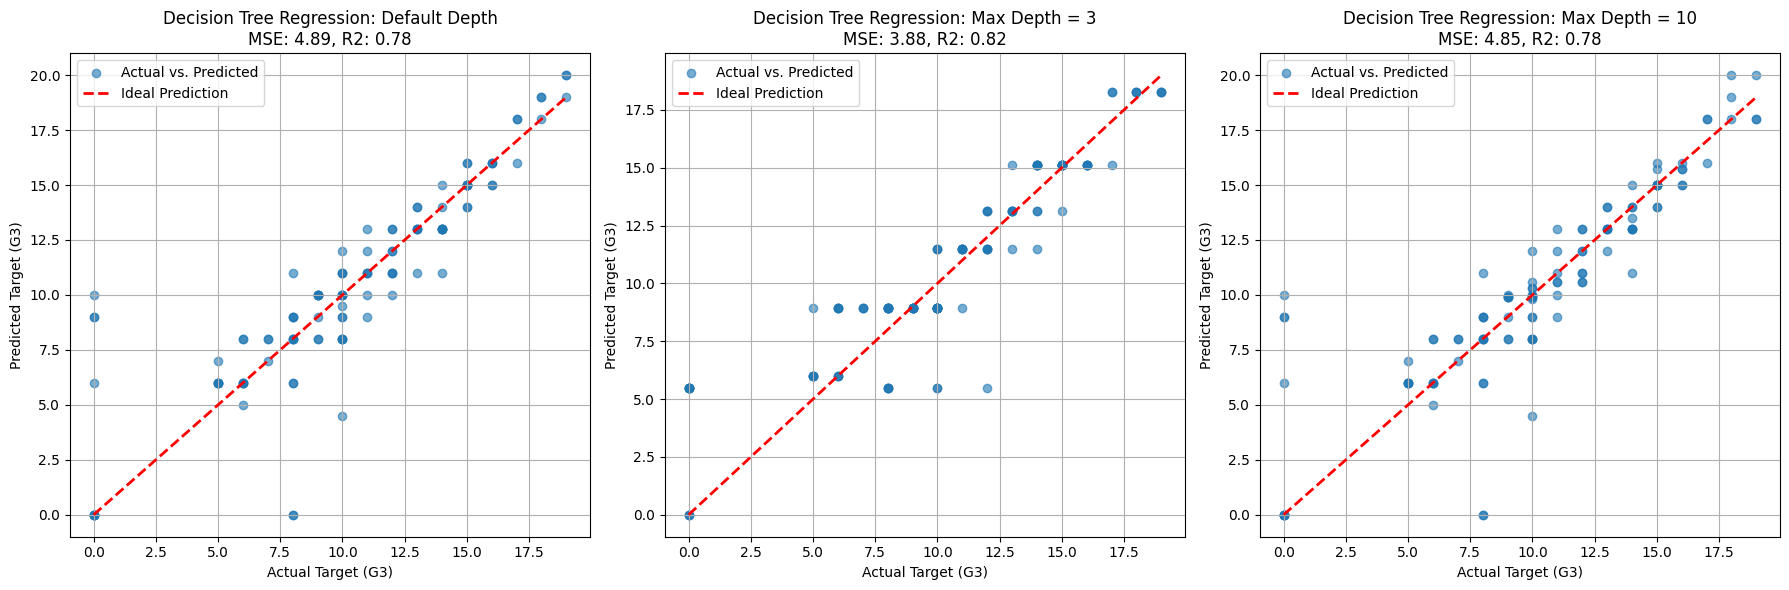


--- Visualizing Decision Tree with Max Depth = 3 ---


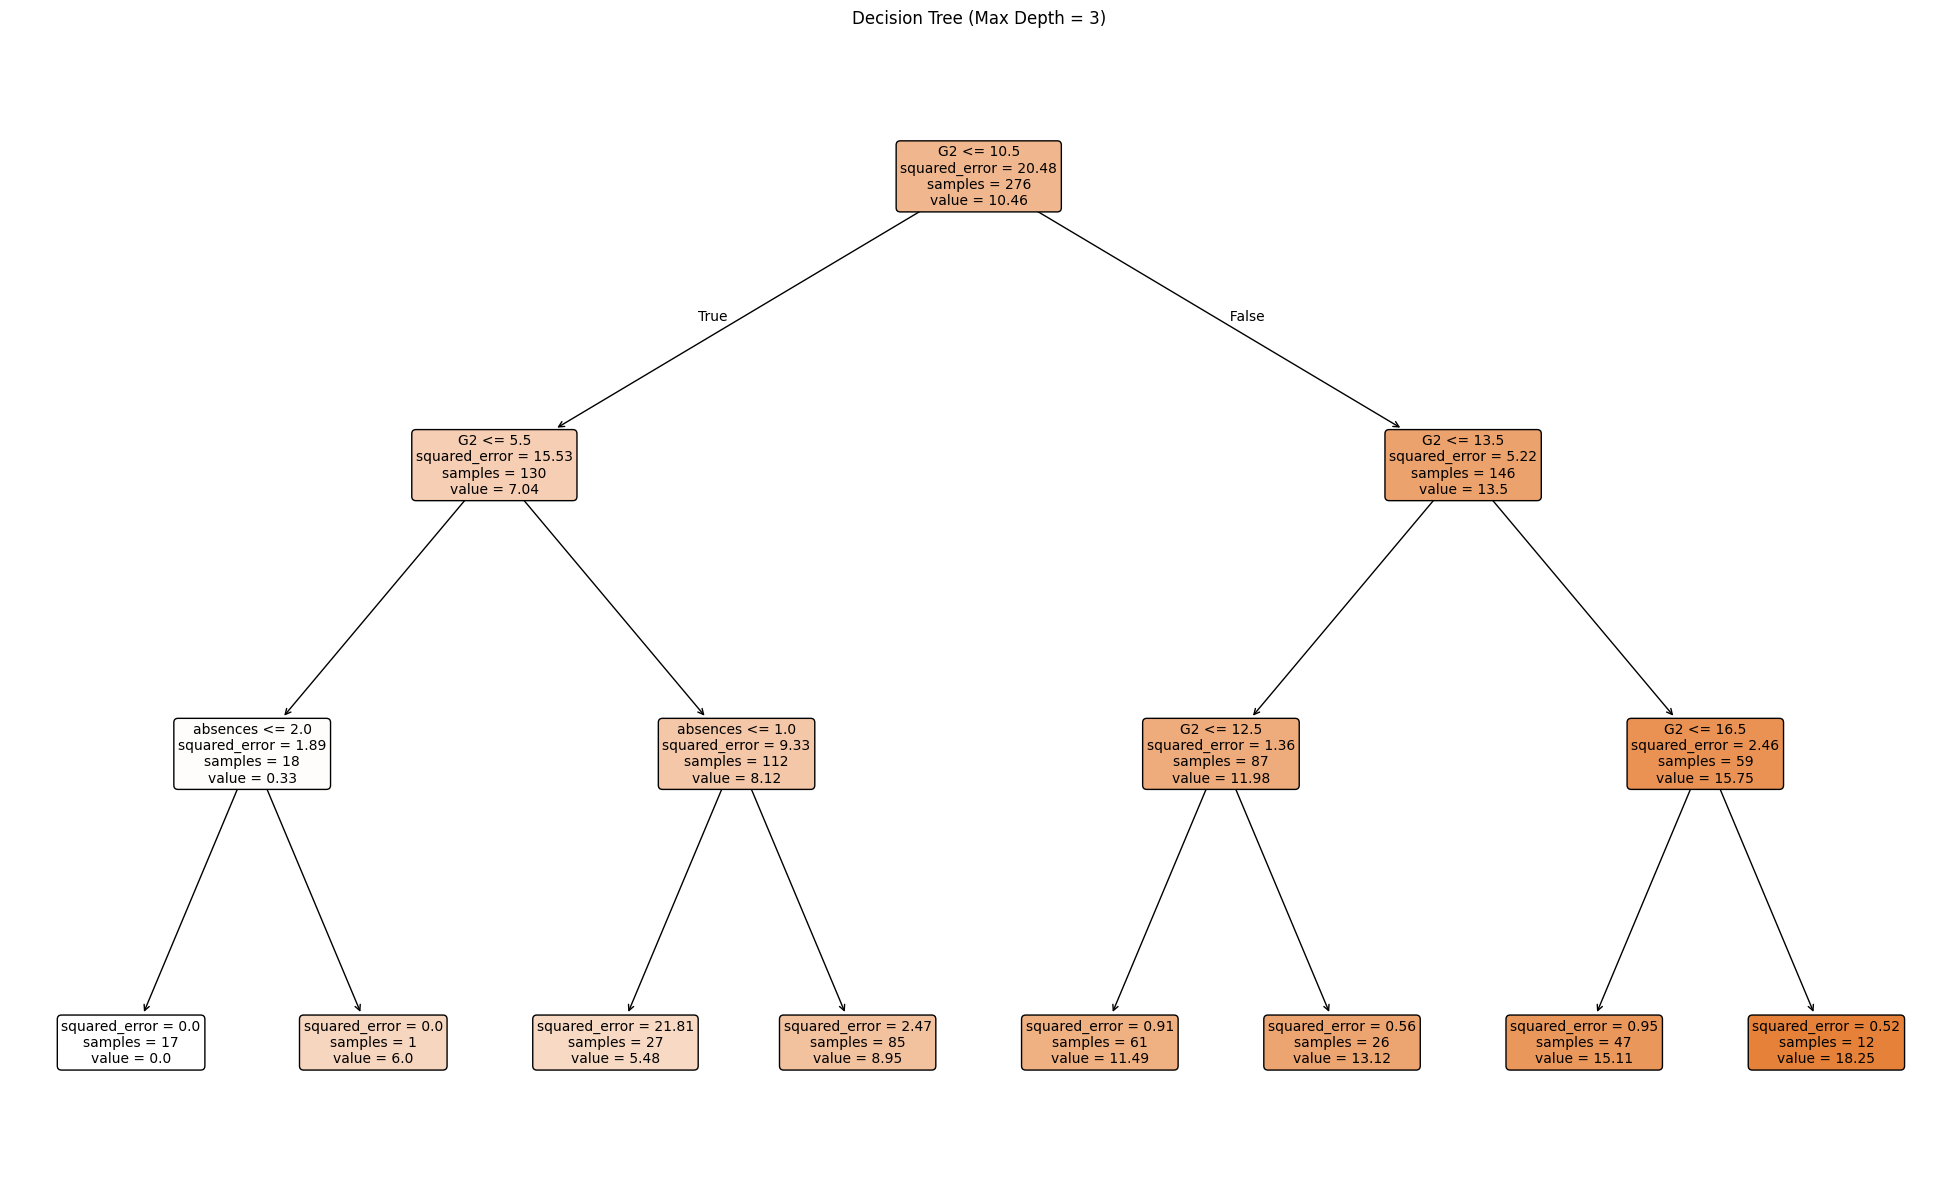

In [ ]:
models = {
    'Default Depth': dt_regressor_1,
    'Max Depth = 3': dt_regressor_2,
    'Max Depth = 10': dt_regressor_3
}

plt.figure(figsize=(18, 6))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n--- {name} ---")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"R-squared (R2) Score: {r2:.4f}")

    plt.subplot(1, 3, i + 1)
    plt.scatter(y_test, y_pred, alpha=0.6, label='Actual vs. Predicted')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Prediction')
    plt.xlabel("Actual Target (G3)")
    plt.ylabel("Predicted Target (G3)")
    plt.title(f"Decision Tree Regression: {name}\nMSE: {mse:.2f}, R2: {r2:.2f}")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

# Optional: Visualize one of the decision trees (e.g., max_depth=3)
# Note: For multiple features, the tree visualization can become very large.
# We'll visualize a shallower tree to keep it readable.
print("\n--- Visualizing Decision Tree with Max Depth = 3 ---")
plt.figure(figsize=(25,15))
# Use the feature_columns list directly as X is now a numpy array
plot_tree(dt_regressor_2, filled=True, feature_names=feature_columns, rounded=True, precision=2, fontsize=10)
plt.title("Decision Tree (Max Depth = 3)")
plt.show()